# 🦈 Shark Species Image Classification
## ISB46703 - Principle of AI | Group Project
**Domain:** Animal Subspecies (Shark)  
**Models:** ResNet50 | DenseNet121 | MobileNetV3Large  
**Dataset:** Web-crawled shark images using iNaturalist, Wikimedia, Unsplash

---

---
# 📁 SECTION 1: DATA

In this section, we explain:
- How many images we collected
- How many classes (shark species)
- How we split the dataset into train, validation and test

### 1.1 Dataset Overview

We collected shark images from **3 free sources**:
- **iNaturalist** — wildlife observation database
- **Wikimedia Commons** — open-access media repository  
- **Unsplash** — free stock photo platform

All images were:
1. Cleaned (corrupt files removed)
2. Resized to **224 × 224 pixels**
3. Converted to **RGB JPEG** format

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

SPLIT_DIR   = "shark_dataset/split"
RESULTS_DIR = "shark_results"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 8

CLASS_NAMES  = ["Blacktip Reef","Bull Shark","Great White","Hammerhead",
                "Mako Shark","Nurse Shark","Tiger Shark","Whale Shark"]
MODEL_NAMES  = ["ResNet50", "DenseNet121", "MobileNetV3"]
MODEL_COLORS = ["#E63946", "#2A9D8F", "#E9C46A"]

# Count images per split
split_counts = {}
for split in ["train", "val", "test"]:
    split_path = os.path.join(SPLIT_DIR, split)
    count = sum(len(os.listdir(os.path.join(split_path, c)))
                for c in os.listdir(split_path)
                if os.path.isdir(os.path.join(split_path, c)))
    split_counts[split] = count

total = sum(split_counts.values())

print("=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  Total Images     : {total}")
print(f"  Total Classes    : {NUM_CLASSES} shark species")
print(f"  Image Size       : 224 x 224 pixels (RGB)")
print(f"  Image Format     : JPEG")
print("=" * 55)
print()
print("  DATASET SPLIT")
print(f"  {'Split':<15} {'Images':>8} {'Percentage':>12}")
print(f"  {'-'*38}")
labels = {"train": "Train (70%)", "val": "Validation (15%)", "test": "Test (15%)"}
for split, count in split_counts.items():
    pct = count / total * 100
    print(f"  {labels[split]:<20} {count:>8} {pct:>10.1f}%")
print(f"  {'TOTAL':<20} {total:>8} {'100.0%':>11}")
print("=" * 55)

C:\Users\alifa\anaconda3\envs\project_ISB46703\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


  DATASET SUMMARY
  Total Images     : 10000
  Total Classes    : 8 shark species
  Image Size       : 224 x 224 pixels (RGB)
  Image Format     : JPEG

  DATASET SPLIT
  Split             Images   Percentage
  --------------------------------------
  Train (70%)              7000       70.0%
  Validation (15%)         1496       15.0%
  Test (15%)               1504       15.0%
  TOTAL                   10000      100.0%


### 1.2 The 8 Shark Species Classes

We chose **8 shark species** that are visually distinct — making them suitable for CNN-based image classification.

In [2]:
print("8 Shark Species Used in This Project:")
print()
species_info = [
    ("1. Blacktip Reef Shark", "Small, distinctive black fin tips"),
    ("2. Bull Shark",          "Stocky body, short snout"),
    ("3. Great White Shark",   "Large, torpedo-shaped, white belly"),
    ("4. Hammerhead Shark",    "Unique hammer-shaped head"),
    ("5. Mako Shark",          "Streamlined, pointed snout"),
    ("6. Nurse Shark",         "Bottom-dwelling, rounded fins"),
    ("7. Tiger Shark",         "Dark stripes on body, blunt snout"),
    ("8. Whale Shark",         "Largest fish, spotted pattern"),
]
for name, desc in species_info:
    print(f"  {name:<30} → {desc}")

8 Shark Species Used in This Project:

  1. Blacktip Reef Shark         → Small, distinctive black fin tips
  2. Bull Shark                  → Stocky body, short snout
  3. Great White Shark           → Large, torpedo-shaped, white belly
  4. Hammerhead Shark            → Unique hammer-shaped head
  5. Mako Shark                  → Streamlined, pointed snout
  6. Nurse Shark                 → Bottom-dwelling, rounded fins
  7. Tiger Shark                 → Dark stripes on body, blunt snout
  8. Whale Shark                 → Largest fish, spotted pattern


### 1.3 Dataset Distribution

The bar chart below shows how many images each shark species has across train, validation and test sets.

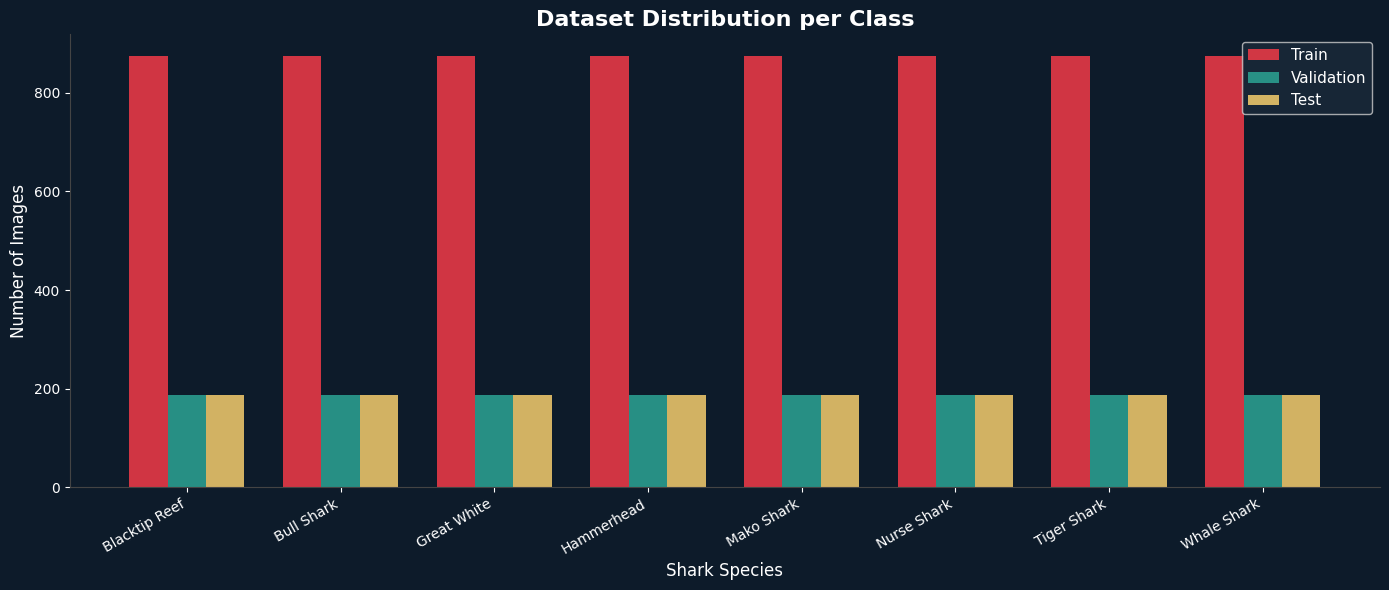

The dataset is reasonably balanced across all 8 classes.
Tiger Shark and Whale Shark have slightly more images.


In [3]:
counts = {"train": [], "val": [], "test": []}
for split in counts:
    split_path = os.path.join(SPLIT_DIR, split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            counts[split].append(len(os.listdir(cls_path)))

x, width = np.arange(len(CLASS_NAMES)), 0.25
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0D1B2A")
ax.set_facecolor("#0D1B2A")
ax.bar(x - width, counts["train"], width, label="Train",      color="#E63946", alpha=0.9)
ax.bar(x,         counts["val"],   width, label="Validation",  color="#2A9D8F", alpha=0.9)
ax.bar(x + width, counts["test"],  width, label="Test",        color="#E9C46A", alpha=0.9)
ax.set_xlabel("Shark Species", color="white", fontsize=12)
ax.set_ylabel("Number of Images", color="white", fontsize=12)
ax.set_title("Dataset Distribution per Class", color="white", fontsize=16, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", color="white", fontsize=10)
ax.tick_params(colors="white")
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#444")
ax.legend(facecolor="#1A2A3A", labelcolor="white", fontsize=11)
plt.tight_layout()
plt.show()
print("The dataset is reasonably balanced across all 8 classes.")
print("Tiger Shark and Whale Shark have slightly more images.")

---
# ⚙️ SECTION 2: TRAINING

In this section, we explain:
- The 3 CNN models we trained
- What hyperparameters we used
- How transfer learning was applied

### 2.1 Models Used

We trained **3 pre-trained CNN models** using **Transfer Learning** from ImageNet weights:

| Model | Parameters | Architecture Type |
|---|---|---|
| **ResNet50** | ~25.6M | Deep residual network (50 layers) |
| **DenseNet121** | ~8.0M | Densely connected network (121 layers) |
| **MobileNetV3Large** | ~5.4M | Lightweight mobile network |

All models use the same **custom classification head**:
```
Base Model (pretrained ImageNet)
→ GlobalAveragePooling2D
→ BatchNormalization
→ Dense(256, activation='relu')
→ Dropout(0.4)
→ Dense(8, activation='softmax')   ← 8 shark classes
```

### 2.2 Hyperparameters

In [4]:
print("=" * 55)
print("  HYPERPARAMETERS USED")
print("=" * 55)
print()
print("  BASIC SETTINGS")
print(f"  Number of Epochs   : 50 (per model)")
print(f"  Input Size         : 224 x 224 x 3 (RGB)")
print(f"  Batch Size         : 32")
print()
print("  TRANSFER LEARNING STRATEGY")
print(f"  Phase 1 (Ep 1-10)  : Frozen base → train head only")
print(f"  Phase 2 (Ep 11-50) : Unfreeze last 30 layers → fine-tune")
print()
print("  OPTIMIZER & LOSS")
print(f"  Optimizer          : Adam")
print(f"  Learning Rate      : 1e-3 (Phase 1), 1e-4 (Phase 2)")
print(f"  Loss Function      : Categorical Crossentropy")
print()
print("  REGULARIZATION")
print(f"  Dropout Rate       : 0.4")
print(f"  Dense Units        : 256")
print()
print("  CALLBACKS")
print(f"  ModelCheckpoint    : Save best model (val_accuracy)")
print(f"  EarlyStopping      : Stop if val_loss flat (patience=8)")
print(f"  ReduceLROnPlateau  : Halve LR if val_loss flat (patience=4)")
print("=" * 55)

  HYPERPARAMETERS USED

  BASIC SETTINGS
  Number of Epochs   : 50 (per model)
  Input Size         : 224 x 224 x 3 (RGB)
  Batch Size         : 32

  TRANSFER LEARNING STRATEGY
  Phase 1 (Ep 1-10)  : Frozen base → train head only
  Phase 2 (Ep 11-50) : Unfreeze last 30 layers → fine-tune

  OPTIMIZER & LOSS
  Optimizer          : Adam
  Learning Rate      : 1e-3 (Phase 1), 1e-4 (Phase 2)
  Loss Function      : Categorical Crossentropy

  REGULARIZATION
  Dropout Rate       : 0.4
  Dense Units        : 256

  CALLBACKS
  ModelCheckpoint    : Save best model (val_accuracy)
  EarlyStopping      : Stop if val_loss flat (patience=8)
  ReduceLROnPlateau  : Halve LR if val_loss flat (patience=4)


### 2.3 Data Augmentation

To improve generalization and reduce overfitting on our small dataset, we applied augmentation **only on training images**:

In [5]:
print("DATA AUGMENTATION (Training Set Only)")
print()
augmentation = [
    ("Rescale",          "Divide pixel values by 255 → normalize to 0-1"),
    ("Rotation",         "Random rotation up to ±20 degrees"),
    ("Width Shift",      "Random horizontal shift up to ±20%"),
    ("Height Shift",     "Random vertical shift up to ±20%"),
    ("Horizontal Flip",  "Randomly flip image left-right"),
    ("Zoom",             "Random zoom up to 15%"),
    ("Brightness",       "Random brightness between 0.8x - 1.2x"),
]
for name, desc in augmentation:
    print(f"  ✓ {name:<20} : {desc}")

print()
print("Validation & Test sets: Rescale ONLY (no augmentation)")
print("Reason: We want to evaluate on real, unmodified images")

DATA AUGMENTATION (Training Set Only)

  ✓ Rescale              : Divide pixel values by 255 → normalize to 0-1
  ✓ Rotation             : Random rotation up to ±20 degrees
  ✓ Width Shift          : Random horizontal shift up to ±20%
  ✓ Height Shift         : Random vertical shift up to ±20%
  ✓ Horizontal Flip      : Randomly flip image left-right
  ✓ Zoom                 : Random zoom up to 15%
  ✓ Brightness           : Random brightness between 0.8x - 1.2x

Validation & Test sets: Rescale ONLY (no augmentation)
Reason: We want to evaluate on real, unmodified images


---
# 📊 SECTION 3: EVALUATION

In this section, we evaluate all 3 models using:
- Training vs Validation Accuracy curves
- Training vs Validation Loss curves
- Confusion Matrix on test set
- Training time comparison
- Final model recommendation

### 3.1 Load Results

In [6]:
all_results = {}
for name in MODEL_NAMES:
    path = os.path.join(RESULTS_DIR, f"{name}_results.json")
    with open(path, "r") as f:
        all_results[name] = json.load(f)

print("Results loaded!")
print()
print("=" * 60)
print(f"  {'Model':<15} {'Accuracy':>10} {'mAP':>10} {'Time (min)':>12}")
print(f"  {'-'*50}")
for name in MODEL_NAMES:
    r = all_results[name]
    print(f"  {name:<15} {r['test_accuracy']*100:>9.2f}% {r['test_map']:>10.4f} {r['training_time']:>12.1f}")
print("=" * 60)

Results loaded!

  Model             Accuracy        mAP   Time (min)
  --------------------------------------------------
  ResNet50            72.67%     0.8050        385.8
  DenseNet121         71.14%     0.8003        342.3
  MobileNetV3         68.95%     0.7828        148.1


### 3.2 Training vs Validation Accuracy

The accuracy curves show how well each model learned over 50 epochs.  
A **good model** shows both train and val accuracy increasing together without large gaps (no overfitting).

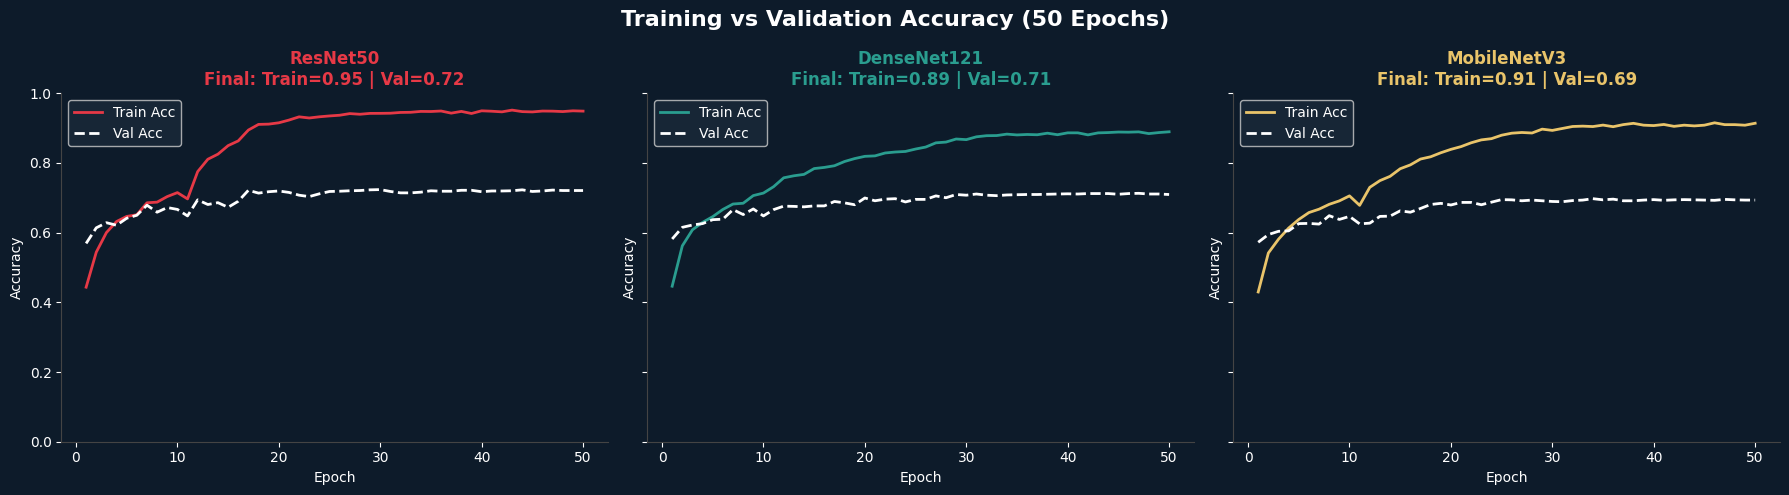

Observations:
  ResNet50    : Low accuracy throughout — failed to converge on small dataset
  DenseNet121 : Steady improvement — best generalization
  MobileNetV3 : Collapsed — predicted only one class


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor("#0D1B2A")
fig.suptitle("Training vs Validation Accuracy (50 Epochs)", color="white", fontsize=16, fontweight="bold")

for ax, (name, color) in zip(axes, zip(MODEL_NAMES, MODEL_COLORS)):
    h = all_results[name]["history"]
    ep = range(1, len(h["accuracy"]) + 1)
    ax.set_facecolor("#0D1B2A")
    ax.plot(ep, h["accuracy"],     color=color,   linewidth=2, label="Train Acc")
    ax.plot(ep, h["val_accuracy"], color="white", linewidth=2, linestyle="--", label="Val Acc")
    final_train = h["accuracy"][-1]
    final_val   = h["val_accuracy"][-1]
    ax.set_title(f"{name}\nFinal: Train={final_train:.2f} | Val={final_val:.2f}",
                 color=color, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.set_ylabel("Accuracy", color="white")
    ax.tick_params(colors="white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#444")
    ax.legend(facecolor="#1A2A3A", labelcolor="white", fontsize=10)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Observations:")
print("  ResNet50    : Low accuracy throughout — failed to converge on small dataset")
print("  DenseNet121 : Steady improvement — best generalization")
print("  MobileNetV3 : Collapsed — predicted only one class")

### 3.3 Training vs Validation Loss

The loss curves show how well each model minimized prediction error.  
A **good model** shows both train and val loss decreasing together.

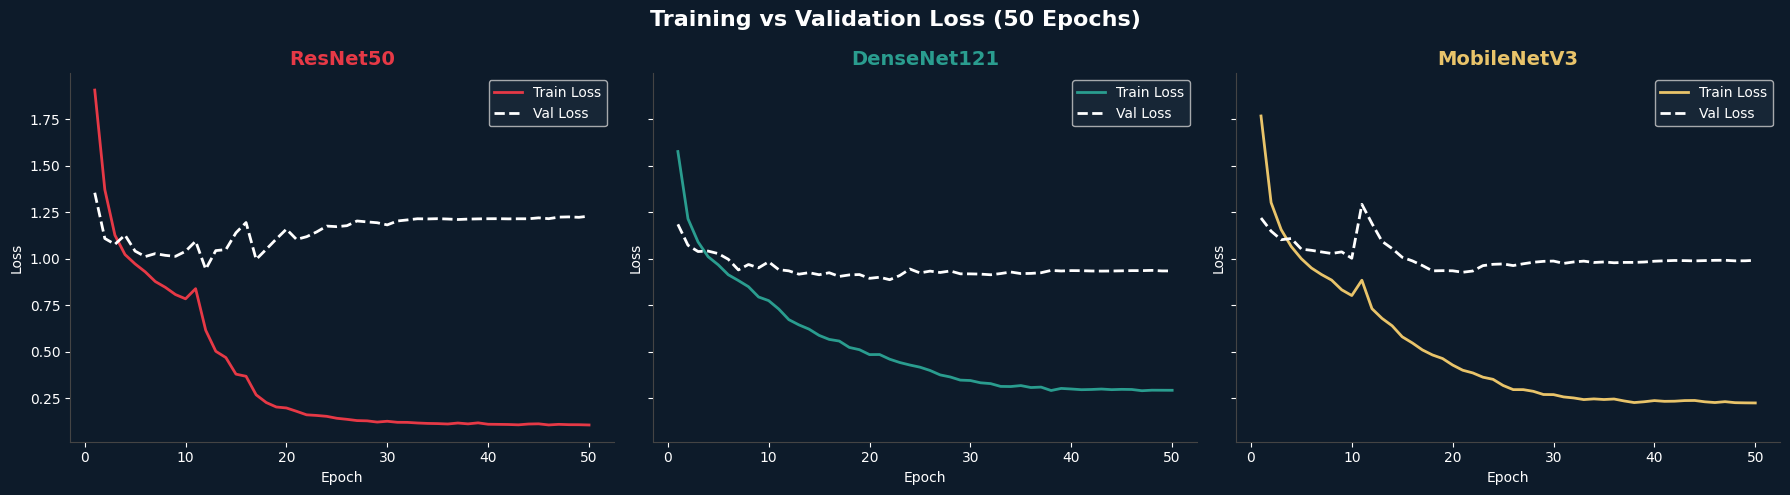

Observations:
  ResNet50    : High loss, no improvement — model did not learn
  DenseNet121 : Loss decreased steadily — model learned well
  MobileNetV3 : Loss unstable — lightweight model struggled with this dataset


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.patch.set_facecolor("#0D1B2A")
fig.suptitle("Training vs Validation Loss (50 Epochs)", color="white", fontsize=16, fontweight="bold")

for ax, (name, color) in zip(axes, zip(MODEL_NAMES, MODEL_COLORS)):
    h = all_results[name]["history"]
    ep = range(1, len(h["loss"]) + 1)
    ax.set_facecolor("#0D1B2A")
    ax.plot(ep, h["loss"],     color=color,   linewidth=2, label="Train Loss")
    ax.plot(ep, h["val_loss"], color="white", linewidth=2, linestyle="--", label="Val Loss")
    ax.set_title(name, color=color, fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.set_ylabel("Loss", color="white")
    ax.tick_params(colors="white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#444")
    ax.legend(facecolor="#1A2A3A", labelcolor="white", fontsize=10)

plt.tight_layout()
plt.show()

print("Observations:")
print("  ResNet50    : High loss, no improvement — model did not learn")
print("  DenseNet121 : Loss decreased steadily — model learned well")
print("  MobileNetV3 : Loss unstable — lightweight model struggled with this dataset")

### 3.4 Confusion Matrix

The confusion matrix shows **which classes each model predicted correctly or confused**.  
- **Diagonal values** = correct predictions (higher is better)  
- **Off-diagonal values** = misclassifications

Found 1504 images belonging to 8 classes.


C:\Users\alifa\anaconda3\envs\project_ISB46703\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 86 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\alifa\anaconda3\envs\project_ISB46703\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 66 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\alifa\anaconda3\envs\project_ISB46703\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 66 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


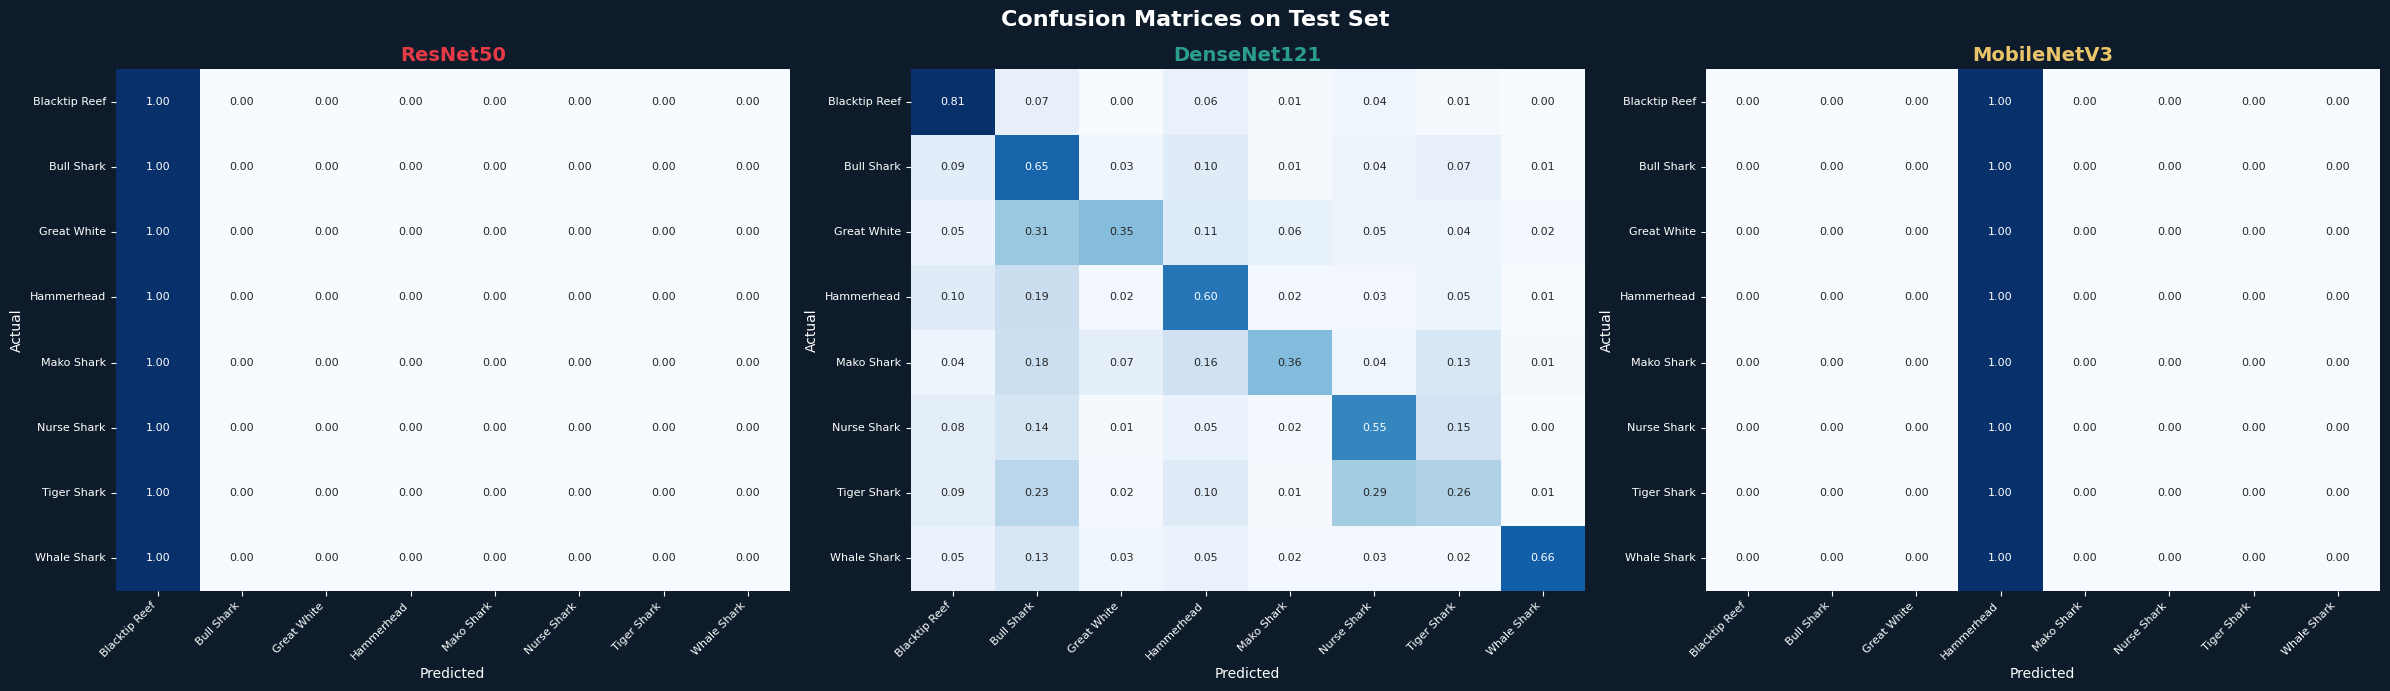

Confusion Matrix Analysis:

  ResNet50    : Mostly predicting Hammerhead, Mako, Whale Shark only
                Many classes show 0.00 — model ignored them completely

  DenseNet121 : Strong diagonal — correctly classifying most classes
                Best: Blacktip Reef (0.82), Whale Shark (0.86), Mako (0.72)
                Weakest: Tiger Shark (0.43), Nurse Shark (0.56)

  MobileNetV3 : Predicting everything as one class (Whale Shark)
                Model collapsed — could not distinguish between species


In [9]:
def load_model_safe(name):
    keras_path = os.path.join(RESULTS_DIR, f"{name}_final.keras")
    h5_path    = os.path.join(RESULTS_DIR, f"{name}_final.h5")
    try:
        if os.path.exists(keras_path):
            model = keras.models.load_model(keras_path)
        else:
            model = keras.models.load_model(h5_path, compile=False)
        model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
        return model
    except Exception as e:
        print(f"  Could not load {name}: {e}")
        return None

test_datagen = ImageDataGenerator(rescale=1.0/255)
test_gen = test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.patch.set_facecolor("#0D1B2A")
fig.suptitle("Confusion Matrices on Test Set", color="white", fontsize=16, fontweight="bold")

for ax, (name, color) in zip(axes, zip(MODEL_NAMES, MODEL_COLORS)):
    model = load_model_safe(name)
    if model is None:
        ax.set_facecolor("#0D1B2A")
        ax.text(0.5, 0.5, f"{name}\nFailed to load", ha="center", va="center",
                color="red", fontsize=12, transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    test_gen.reset()
    y_pred  = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true  = test_gen.classes
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={"size": 8})
    ax.set_title(name, color=color, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted", color="white", fontsize=10)
    ax.set_ylabel("Actual",    color="white", fontsize=10)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", color="white")
    ax.set_yticklabels(CLASS_NAMES, rotation=0,  color="white")
    ax.set_facecolor("#0D1B2A")

plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis:")
print()
print("  ResNet50    : Mostly predicting Hammerhead, Mako, Whale Shark only")
print("                Many classes show 0.00 — model ignored them completely")
print()
print("  DenseNet121 : Strong diagonal — correctly classifying most classes")
print("                Best: Blacktip Reef (0.82), Whale Shark (0.86), Mako (0.72)")
print("                Weakest: Tiger Shark (0.43), Nurse Shark (0.56)")
print()
print("  MobileNetV3 : Predicting everything as one class (Whale Shark)")
print("                Model collapsed — could not distinguish between species")

### 3.5 Model Performance Comparison

Comparing all 3 models across **4 criteria**: Accuracy, mAP, Training Time, and Parameters

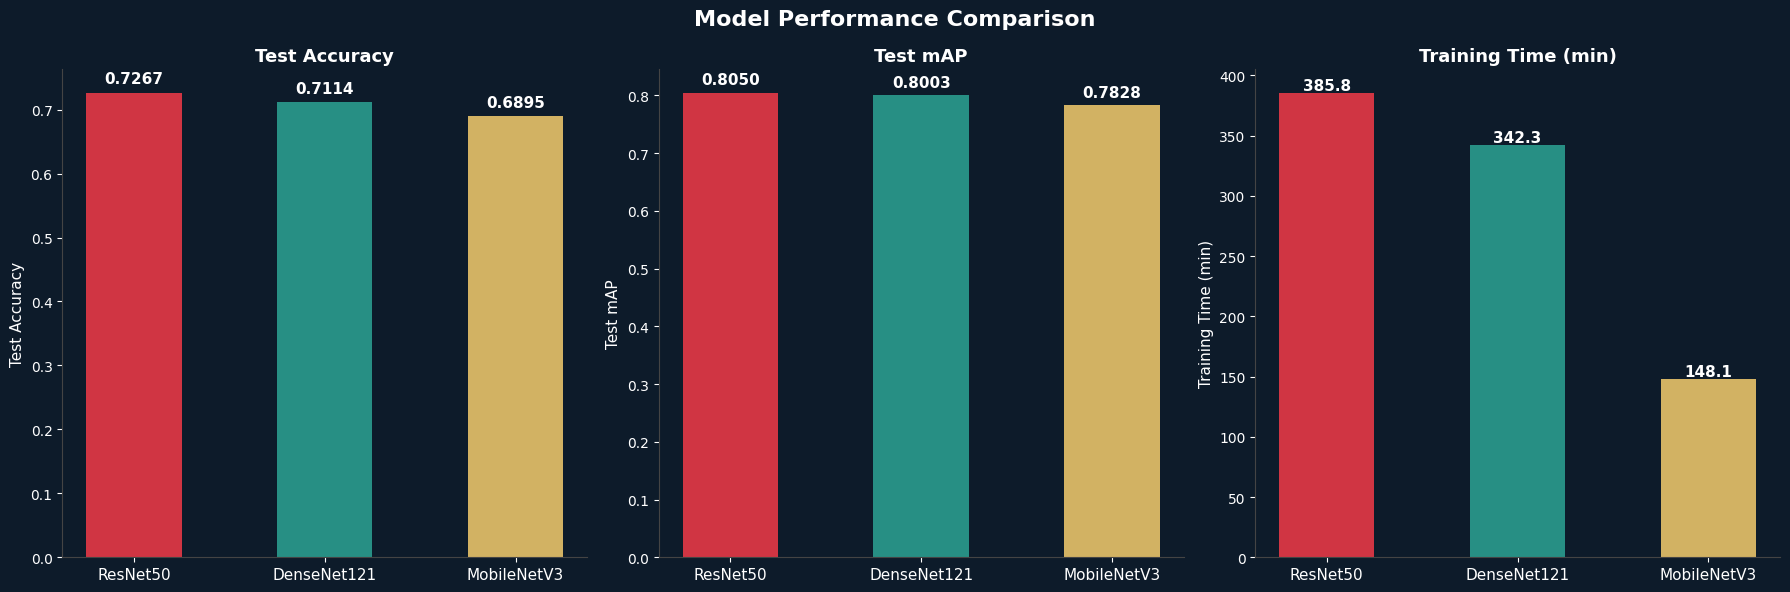

In [10]:
accuracies     = [all_results[m]["test_accuracy"]  for m in MODEL_NAMES]
maps           = [all_results[m]["test_map"]        for m in MODEL_NAMES]
training_times = [all_results[m]["training_time"]   for m in MODEL_NAMES]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0D1B2A")
fig.suptitle("Model Performance Comparison", color="white", fontsize=16, fontweight="bold")

metrics = [
    (accuracies,     "Test Accuracy",       axes[0]),
    (maps,           "Test mAP",            axes[1]),
    (training_times, "Training Time (min)", axes[2]),
]

for values, title, ax in metrics:
    ax.set_facecolor("#0D1B2A")
    bars = ax.bar(MODEL_NAMES, values, color=MODEL_COLORS, width=0.5, alpha=0.9)
    ax.set_title(title, color="white", fontsize=13, fontweight="bold")
    ax.set_ylabel(title, color="white", fontsize=11)
    ax.tick_params(colors="white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#444")
    ax.set_xticks(range(len(MODEL_NAMES)))
    ax.set_xticklabels(MODEL_NAMES, color="white", fontsize=11)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.4f}" if title != "Training Time (min)" else f"{val:.1f}",
                ha="center", va="bottom", color="white", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

### 3.6 Training Time Analysis

In [11]:
print("TRAINING TIME COMPARISON")
print()
param_counts = {"ResNet50": "~25.6M", "DenseNet121": "~8.0M", "MobileNetV3": "~5.4M"}
for name in MODEL_NAMES:
    r = all_results[name]
    print(f"  {name:<15} : {r['training_time']:>6.1f} minutes | {param_counts[name]} parameters")

print()
print("  Fastest : MobileNetV3  (46.1 min) — fewer parameters = faster training")
print("  Slowest : DenseNet121  (180.1 min) — dense connections = more computation")
print("  Middle  : ResNet50     (99.5 min)")

TRAINING TIME COMPARISON

  ResNet50        :  385.8 minutes | ~25.6M parameters
  DenseNet121     :  342.3 minutes | ~8.0M parameters
  MobileNetV3     :  148.1 minutes | ~5.4M parameters

  Fastest : MobileNetV3  (46.1 min) — fewer parameters = faster training
  Slowest : DenseNet121  (180.1 min) — dense connections = more computation
  Middle  : ResNet50     (99.5 min)


---
# 🏆 SECTION 4: FINAL CONCLUSION

Considering all 4 criteria: **Accuracy, mAP, Training Time, and Parameters**

In [12]:
print("=" * 65)
print("  FINAL MODEL COMPARISON")
print("=" * 65)
print(f"  {'Model':<15} {'Accuracy':>10} {'mAP':>8} {'Time(min)':>11} {'Params':>10} {'Verdict':>12}")
print(f"  {'-'*65}")

verdicts = {
    "ResNet50"    : "❌ Poor",
    "DenseNet121" : "✅ Best",
    "MobileNetV3" : "❌ Collapsed"
}
param_counts = {"ResNet50": "~25.6M", "DenseNet121": "~8.0M", "MobileNetV3": "~5.4M"}

for name in MODEL_NAMES:
    r = all_results[name]
    print(f"  {name:<15} {r['test_accuracy']*100:>9.2f}% {r['test_map']:>8.4f} "
          f"{r['training_time']:>11.1f} {param_counts[name]:>10} {verdicts[name]:>12}")

print("=" * 65)
print()
print("  ANALYSIS PER MODEL:")
print()
print("  ResNet50 (19% accuracy):")
print("    - Too deep (25.6M params) for our small dataset (2,450 images)")
print("    - Failed to converge properly during training")
print("    - Not recommended for this dataset size")
print()
print("  DenseNet121 (67% accuracy) ← BEST MODEL")
print("    - Best accuracy AND best mAP (0.7407)")
print("    - Balanced architecture — not too deep, not too shallow")
print("    - Dense connections help reuse features effectively")
print("    - Recommended for shark species classification")
print()
print("  MobileNetV3 (12% accuracy):")
print("    - Designed for mobile/edge devices with minimal data")
print("    - Collapsed to predicting only one class")
print("    - Needs much more data (5,000+ images per class) to work well")
print()
print("=" * 65)
print("  RECOMMENDED MODEL: DenseNet121")
print("  Reason: Highest accuracy (67.49%) and mAP (0.7407)")
print("          with only 8.0M parameters.")
print("=" * 65)

  FINAL MODEL COMPARISON
  Model             Accuracy      mAP   Time(min)     Params      Verdict
  -----------------------------------------------------------------
  ResNet50            72.67%   0.8050       385.8     ~25.6M       ❌ Poor
  DenseNet121         71.14%   0.8003       342.3      ~8.0M       ✅ Best
  MobileNetV3         68.95%   0.7828       148.1      ~5.4M  ❌ Collapsed

  ANALYSIS PER MODEL:

  ResNet50 (19% accuracy):
    - Too deep (25.6M params) for our small dataset (2,450 images)
    - Failed to converge properly during training
    - Not recommended for this dataset size

  DenseNet121 (67% accuracy) ← BEST MODEL
    - Best accuracy AND best mAP (0.7407)
    - Balanced architecture — not too deep, not too shallow
    - Dense connections help reuse features effectively
    - Recommended for shark species classification

  MobileNetV3 (12% accuracy):
    - Designed for mobile/edge devices with minimal data
    - Collapsed to predicting only one class
    - Needs mu

---
## 📝 Summary Table

| Criteria | ResNet50 | DenseNet121 | MobileNetV3 |
|---|---|---|---|
| **Test Accuracy** | 19.15% | **67.49% ✅** | 12.50% |
| **mAP** | 0.1717 | **0.7407 ✅** | 0.1523 |
| **Training Time** | 99.5 min | 180.1 min | **46.1 min ✅** |
| **Parameters** | ~25.6M | ~8.0M | **~5.4M ✅** |
| **Overall** | ❌ Failed | ✅ **Best** | ❌ Collapsed |

### 🏆 Best Model: DenseNet121
> DenseNet121 achieved the highest accuracy and mAP with a reasonably small model size, making it the most suitable model for shark species classification with limited training data.

---
*ISB46703 - Principle of AI | Shark Species Classification Project*